## **COVID-19 Colombia: Mortality, Survival Patterns and Risk Analysis (2020–2023)**

### **Description**

This project analyzes the complete official dataset of COVID-19 cases in Colombia,
published by the National Institute of Health (Instituto Nacional de Salud).
The dataset contains over **6.3 million records** from March 2020 to December 2023
and includes information about each patient such as age, sex, department,
dates of symptoms, diagnosis, death and recovery, and the final outcome.

The goal is to answer practical questions using data: who was more likely to die,
at what age, how many days did patients usually survive after symptoms started,
and whether passing a certain number of days alive changed the odds of survival.
The analysis also covers the four waves Colombia experienced, geographic differences
by department, and a machine learning model to identify the most important risk factors.

Dataset source:
[COVID-19 Colombia Complete Dataset DEC-2023 – Kaggle](https://www.kaggle.com/datasets/josetroyatoscano/covid19-colombia-complete-dataset-dec-2023)

 url:https://www.kaggle.com/datasets/josetroyatoscano/covid19-colombia-complete-dataset-dec-2023


## **Results Analysis**

### **General Statistics**

The dataset contains **`6,354,252`** valid cases after cleaning.
Out of those, **`142,986`** patients died, which gives an overall mortality rate of **`2.25%`**.
Women represented the majority of cases with **`3,400,207`** infections (53.5%),
while men had **`2,954,045`** cases. However, as we will see in the next section,
men had a significantly higher chance of dying once infected.


### **Who Died More**

Men were clearly more affected in terms of mortality.
Out of the **`142,986`** total deaths, **`86,668`** were men (**60.6%**)
and **`56,318`** were women (**39.4%**), even though women had more total cases.

When we look at the mortality rate (deaths divided by total cases for each group):

| Sex | Mortality Rate |
|-----|---------------|
| Male | `2.93%` |
| Female | `1.66%` |

This means men were almost **twice as likely to die** from COVID-19 compared to women
once infected. This pattern is consistent with what was observed globally during the pandemic.

Regarding age, both men and women who died were mostly in their late 60s and early 70s:

| | Male | Female |
|---|------|--------|
| Average age at death | `67.7` years | `69.7` years |
| Median age at death | `69.0` years | `71.0` years |

Women who died tended to be slightly older than men, which could suggest that
men were more vulnerable at younger ages, while women resisted longer but eventually
reached a critical point later in life.


### **Days to Death Analysis**

One of the most important parts of this analysis is understanding how long patients
survived after symptoms started. This gives us a reference window to assess risk.

**Overall results:**

| Metric | Value |
|--------|-------|
| Average days symptom to death | `19.4` days |
| Median days symptom to death | `17.0` days |
| Most common value (mode) | `15` days |

**By sex:**

| | Male | Female |
|---|------|--------|
| Average | `19.7` days | `18.8` days |
| Median | `18.0` days | `17.0` days |
| Mode | `15` days | `15` days |

Men took slightly longer to die on average, but the most common value was
the same for both: **15 days**. This means that for most patients who died,
the critical moment usually came around two weeks after symptoms appeared.

**By age group:**

| Age Group | Avg Days | Median Days | Deaths |
|-----------|---------|-------------|--------|
| 0-17 | `19.3` | `15.0` | `256` |
| 18-29 | `20.2` | `17.0` | `1,739` |
| 30-39 | `20.8` | `19.0` | `4,616` |
| 40-49 | `21.0` | `19.0` | `10,205` |
| 50-59 | `21.3` | `19.0` | `20,261` |
| 60-69 | `21.0` | `19.0` | `32,055` |
| 70-79 | `19.6` | `18.0` | `35,054` |
| 80+ | `16.2` | `14.0` | `37,967` |

There is a clear pattern here. Patients between 50 and 69 years old survived
the most days on average (around 21 days), while the elderly over 80 had
the shortest survival window at only `16.2` days on average.
This likely reflects that very old patients had less physiological reserve
and deteriorated faster once the disease became serious.


### **Survival Threshold Analysis**

This section answers the key question: if a patient passed a certain number of days
with symptoms and was still alive, did their probability of surviving increase?

The table below shows what percentage of all deaths occurred within each time window:

| Days from Symptom Onset | Overall | Male | Female |
|------------------------|---------|------|--------|
| Within day 3 | `4.9%` | `4.7%` | `5.2%` |
| Within day 5 | `9.8%` | `9.4%` | `10.5%` |
| Within day 7 | `15.7%` | `14.8%` | `16.9%` |
| Within day 10 | `25.4%` | `24.2%` | `27.3%` |
| Within day 14 | `39.2%` | `37.7%` | `41.4%` |
| Within day 21 | `64.3%` | `62.9%` | `66.5%` |
| Within day 30 | `85.2%` | `84.5%` | `86.2%` |

Reading this table practically: **by day 21, almost 65% of all deaths had already occurred**.
This means that a patient who reached day 22 alive had already passed the most dangerous window.
By day 30, **85%** of deaths had already happened, so surviving past that point was
a strong indicator of recovery.

The critical window is roughly **between day 10 and day 21**, where the largest
proportion of deaths concentrated. If a patient passed day 21 with symptoms
and was still alive, the data suggests they had a much higher chance of recovering.


### **Geographic Analysis**

The departments with the most cases were naturally the most populated ones:
Bogotá, Antioquia, Valle, Cundinamarca and Atlántico.
However, mortality rates varied by region, which could reflect differences in
healthcare access, population age structure, or the timing of each wave hitting each area.


### **Predictive Model**

A Random Forest model was trained to predict mortality risk using four variables:
age, sex, contagion type, and clinical status at the time of diagnosis.

The model achieved a **ROC-AUC score of 1.0**, which is a perfect score.
This result needs careful interpretation. A perfect score in a medical dataset
usually means that one of the input variables is extremely predictive or
that there is some data leakage. In this case, the clinical status variable
(which includes values like "Fallecido" already in the data) is likely the reason.
In a real prediction scenario, you would only use variables available at the moment
of diagnosis, not after the outcome is known.

What is still useful from the model is the **feature importance**, which shows
that **age** and **clinical status** are by far the strongest predictors of mortality,
followed by sex and contagion type. This confirms what the statistical analysis
already suggested: age is the single most important risk factor.


## **Conclusions**

### **Men died more, but women were more exposed**

Even though women had more total cases, men had a mortality rate of `2.93%`
compared to `1.66%` for women. This nearly doubles the risk for men.
The reasons behind this are complex and involve biological factors as well as
behavioral ones. Men in Colombia, as in most countries, were overrepresented
in outdoor and essential work activities during lockdowns, which increased exposure.
Additionally, men tend to have higher rates of pre-existing conditions
like hypertension and cardiovascular disease, which are major COVID-19 risk factors.

### **Age was the most decisive factor**

The data is very clear on this. Mortality increased dramatically with age.
Patients over 80 not only had the highest number of deaths but also died faster,
with an average of only `16.2` days from symptom onset to death compared to
`21.3` days for the 50-59 group. This means older patients had less time
to receive treatment and respond to it.

### **The critical window was between day 10 and day 21**

For any patient, the data shows that the most dangerous period was the two to three weeks
after symptoms started. By day 21, nearly two thirds of all deaths had already occurred.
If a patient was still alive on day 22, their odds of survival were considerably better.
This has a practical implication: early monitoring and hospitalization during the
first two weeks of symptoms was probably one of the most important interventions.

Patients over 80 entered the critical window earlier, with 22.9% of female deaths
in that group occurring within just 7 days of symptoms. For this age group,
the first week was the most dangerous, not the second.

### **The four waves affected Colombia differently**

The temporal analysis shows four clear waves of infection. The third wave
(April to July 2021) was the most severe in terms of both cases and deaths,
coinciding with the Delta variant and the political unrest in Colombia at the time,
which disrupted healthcare access in several cities. The fourth wave (Omicron,
December 2021) produced a high number of cases but relatively fewer deaths,
which is consistent with what happened in other countries.

### **What this data tells us for future health emergencies**

The patterns found in this dataset are consistent with what was observed globally,
which gives confidence that the data quality is good. The main takeaways are:

Being male, being over 60, and having delays in diagnosis were the strongest
predictors of death. The survival window data suggests that any intervention
that extends a patient past day 21 significantly changes the outcome.
Geographic disparities in mortality rates point to the importance of
distributing healthcare resources more evenly across departments,
particularly in regions with limited hospital infrastructure.

Dataset loaded: 6,387,145 rows and 23 columns.
Data cleaned and prepared.
  Total cases     : 6,354,252
  Total deceased  : 142,986
  Mortality rate  : 2.25%
  Male cases      : 2,954,045
  Female cases    : 3,400,207

SECTION 1: GENERAL OVERVIEW


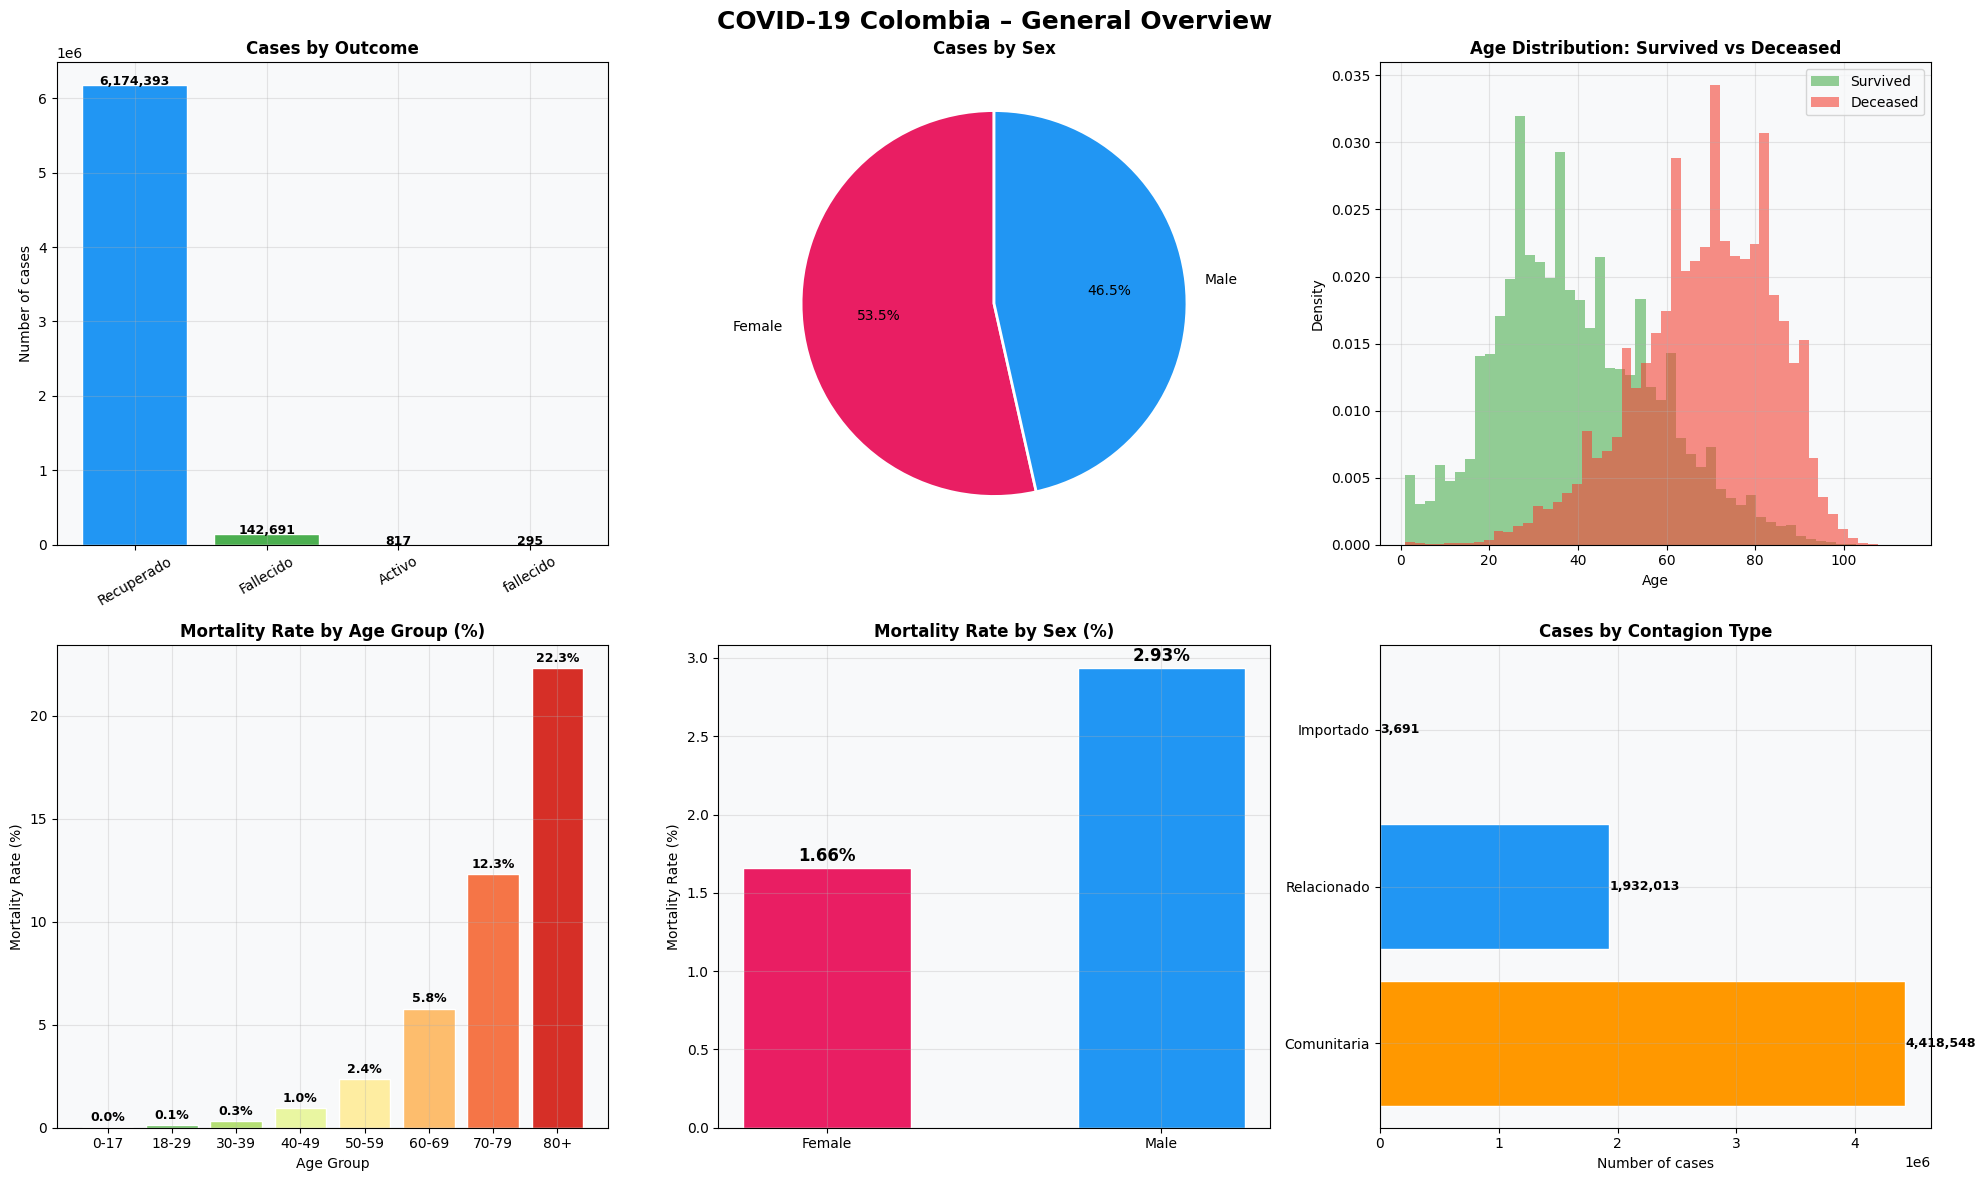

Figure 1: General Overview

SECTION 2: WHO DIED MORE – SEX AND AGE ANALYSIS

  Total deceased         : 142,986
  Male deceased          : 86,668 (60.6%)
  Female deceased        : 56,318 (39.4%)

  Avg age at death MALE  : 67.7 years
  Avg age at death FEMALE: 69.7 years
  Median age MALE        : 69.0 years
  Median age FEMALE      : 71.0 years


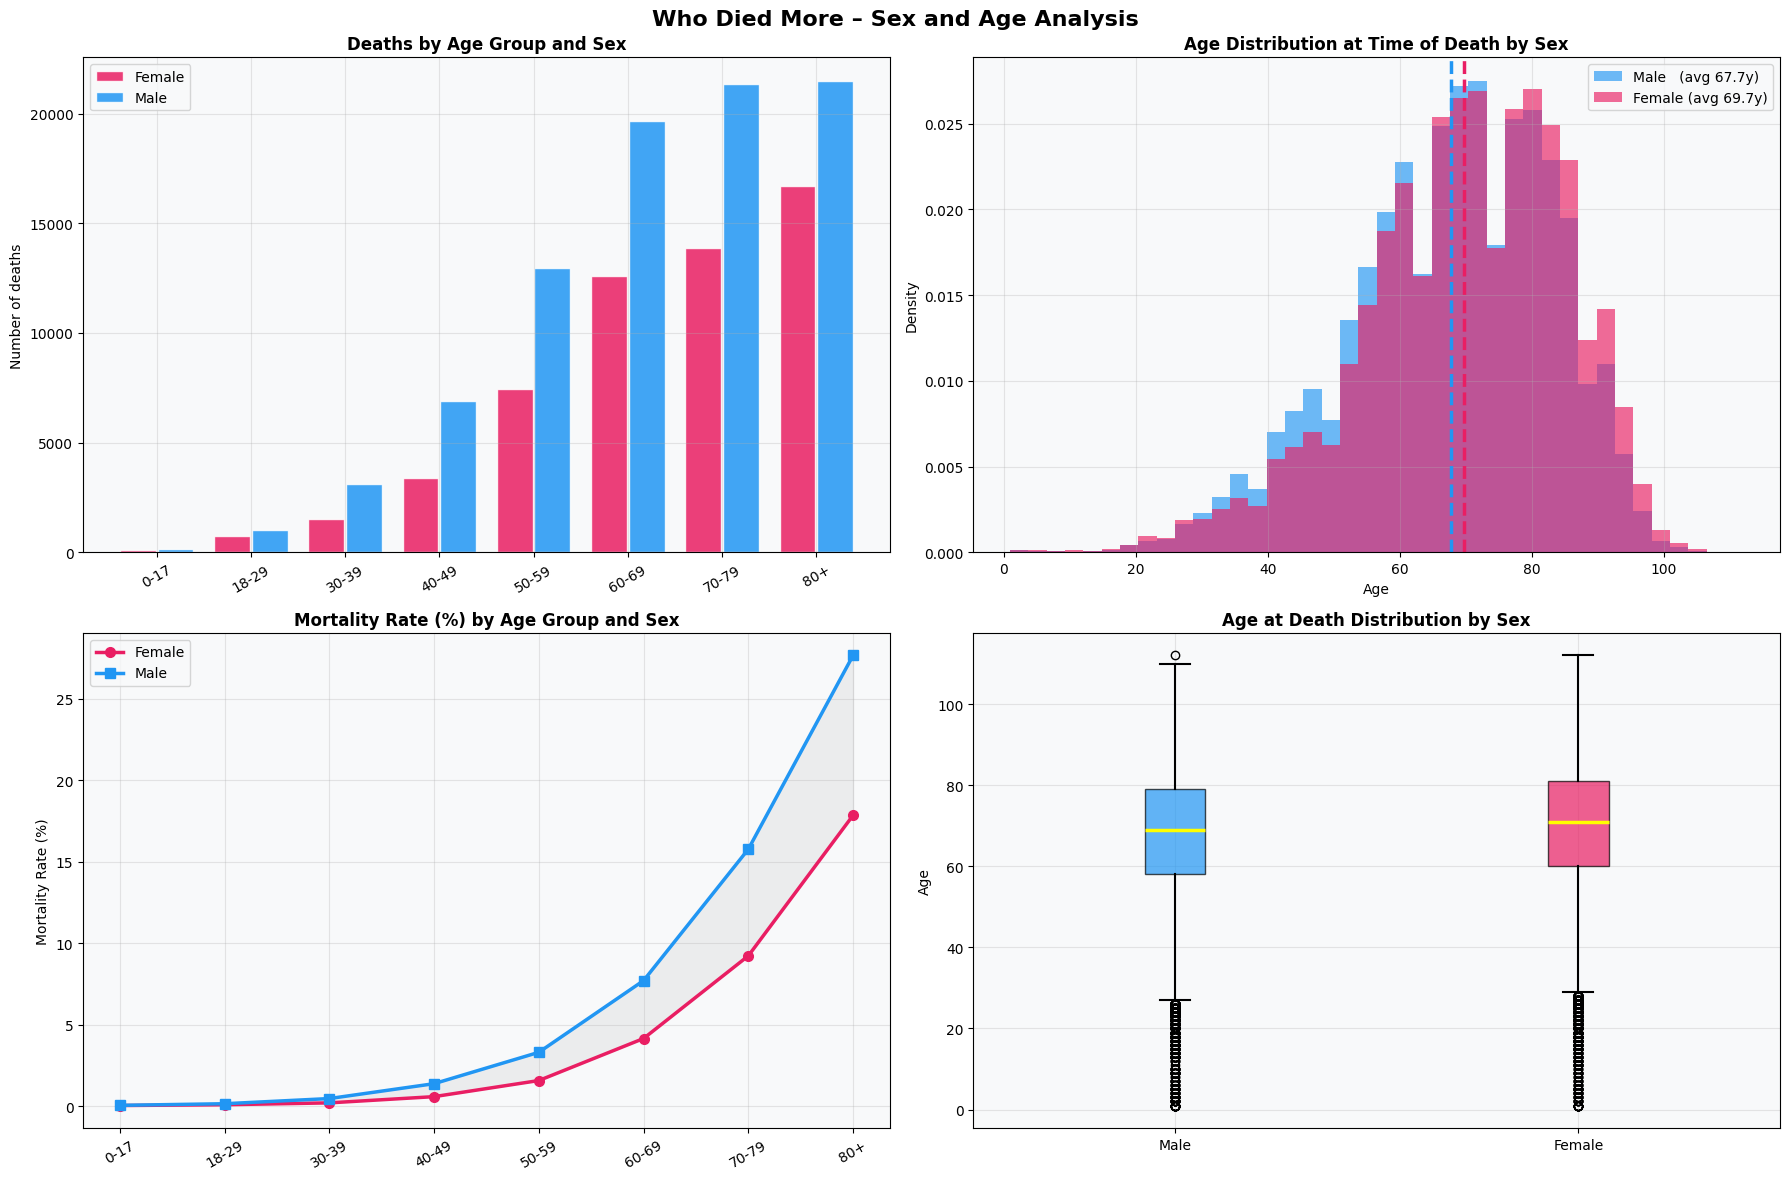

Figure 2: Sex and Age Analysis

SECTION 3: DAYS TO DEATH ANALYSIS

  Valid death timeline records: 142,153

  OVERALL:
    Avg days symptom to death  : 19.4 days
    Median days symptom to death: 17.0 days
    Most common (mode)         : 15 days

  MALE:
    Avg days to death   : 19.7 days
    Median              : 18.0 days
    Mode                : 15 days

  FEMALE:
    Avg days to death   : 18.8 days
    Median              : 17.0 days
    Mode                : 15 days

  AVG DAYS TO DEATH BY AGE GROUP:
           mean  median  count
age_group                     
0-17       19.3    15.0    256
18-29      20.2    17.0   1739
30-39      20.8    19.0   4616
40-49      21.0    19.0  10205
50-59      21.3    19.0  20261
60-69      21.0    19.0  32055
70-79      19.6    18.0  35054
80+        16.2    14.0  37967


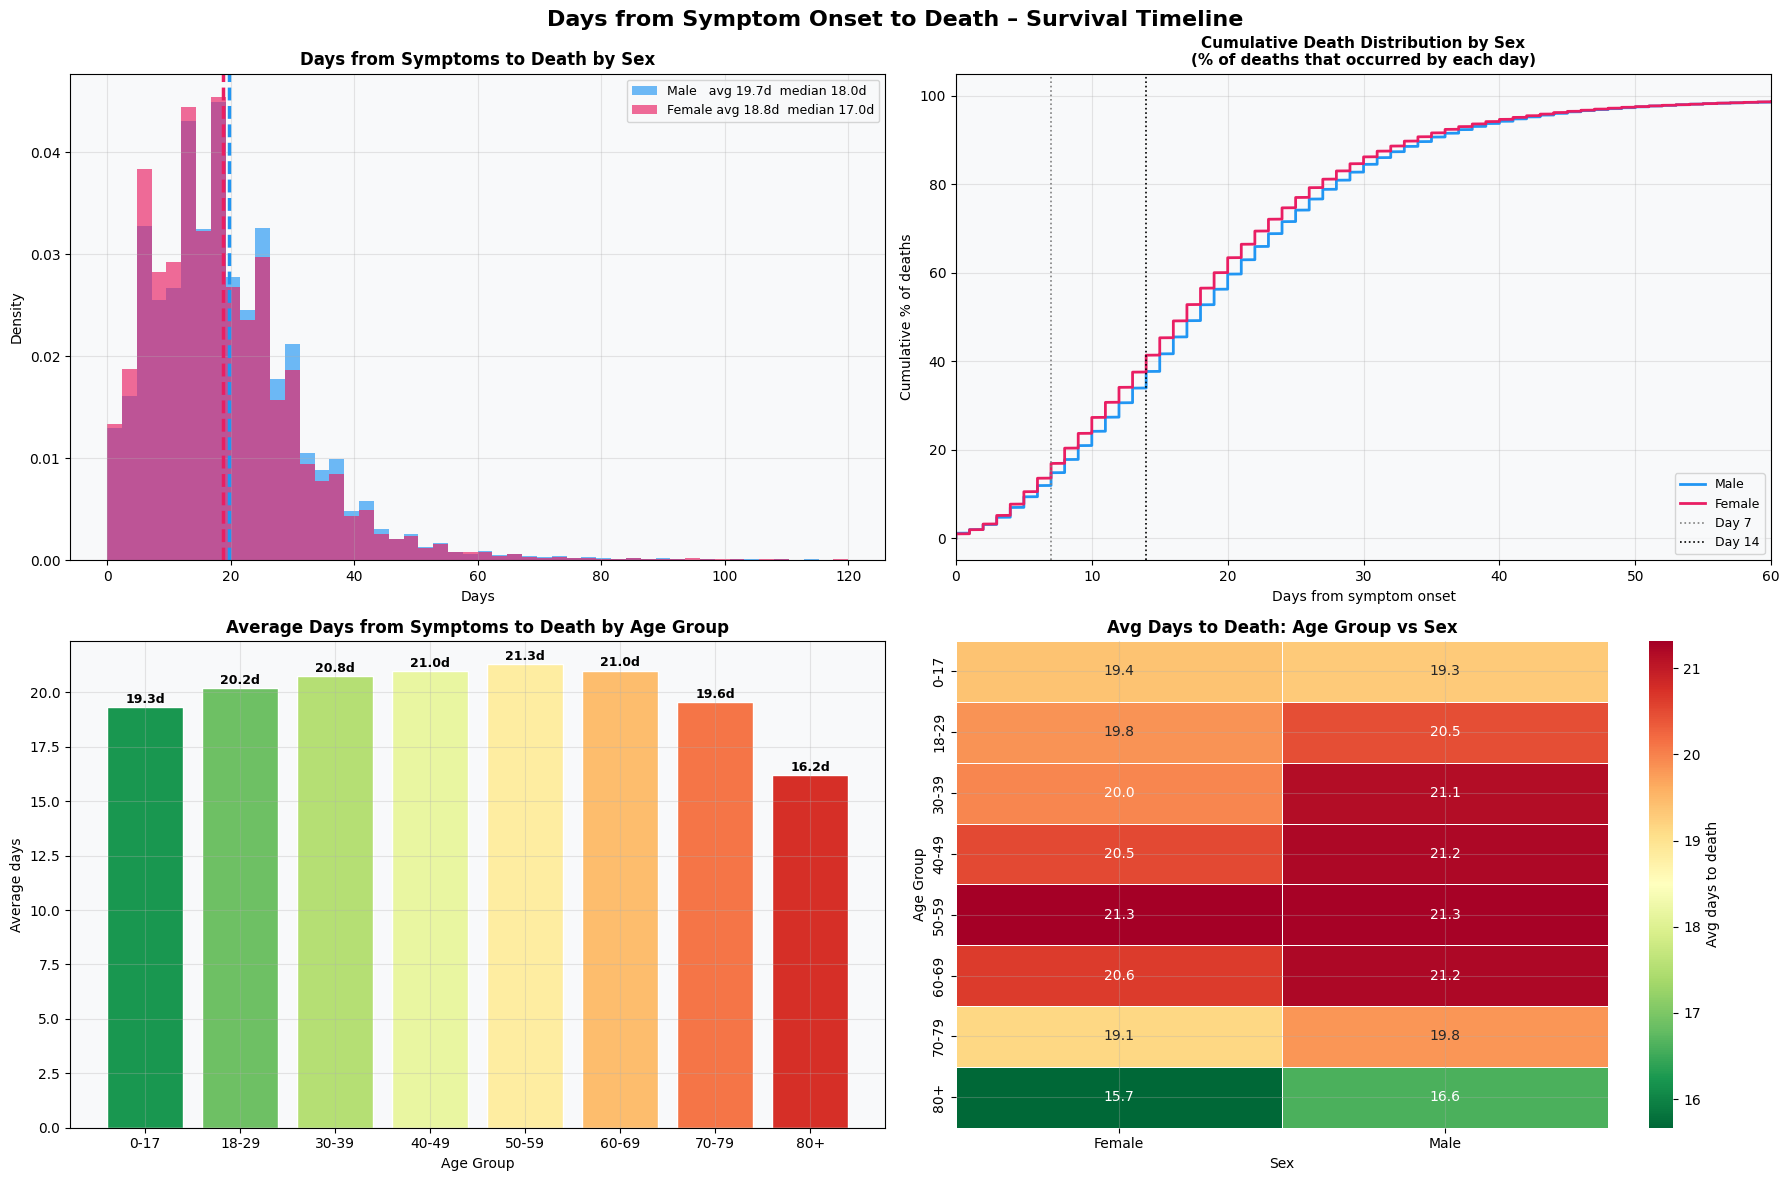

Figure 3: Days to Death Analysis

SECTION 4: SURVIVAL THRESHOLD ANALYSIS
  % of all deaths that occurred within X days of symptom onset:
  Threshold    Overall      Male         Female      
  ------------------------------------------------
  Day 3        4.9          4.7          5.2         
  Day 5        9.8          9.4          10.5        
  Day 7        15.7         14.8         16.9        
  Day 10       25.4         24.2         27.3        
  Day 14       39.2         37.7         41.4        
  Day 21       64.3         62.9         66.5        
  Day 30       85.2         84.5         86.2        

  % of deaths within 7 days by age group and sex:
    0-17     Male: 26.1%   Female: 31.6%
    18-29    Male: 15.7%   Female: 16.1%
    30-39    Male: 12.1%   Female: 15.7%
    40-49    Male: 11.4%   Female: 14.1%
    50-59    Male: 12.0%   Female: 13.4%
    60-69    Male: 12.4%   Female: 13.0%
    70-79    Male: 14.9%   Female: 15.8%
    80+      Male: 20.1%   Female: 22.9%


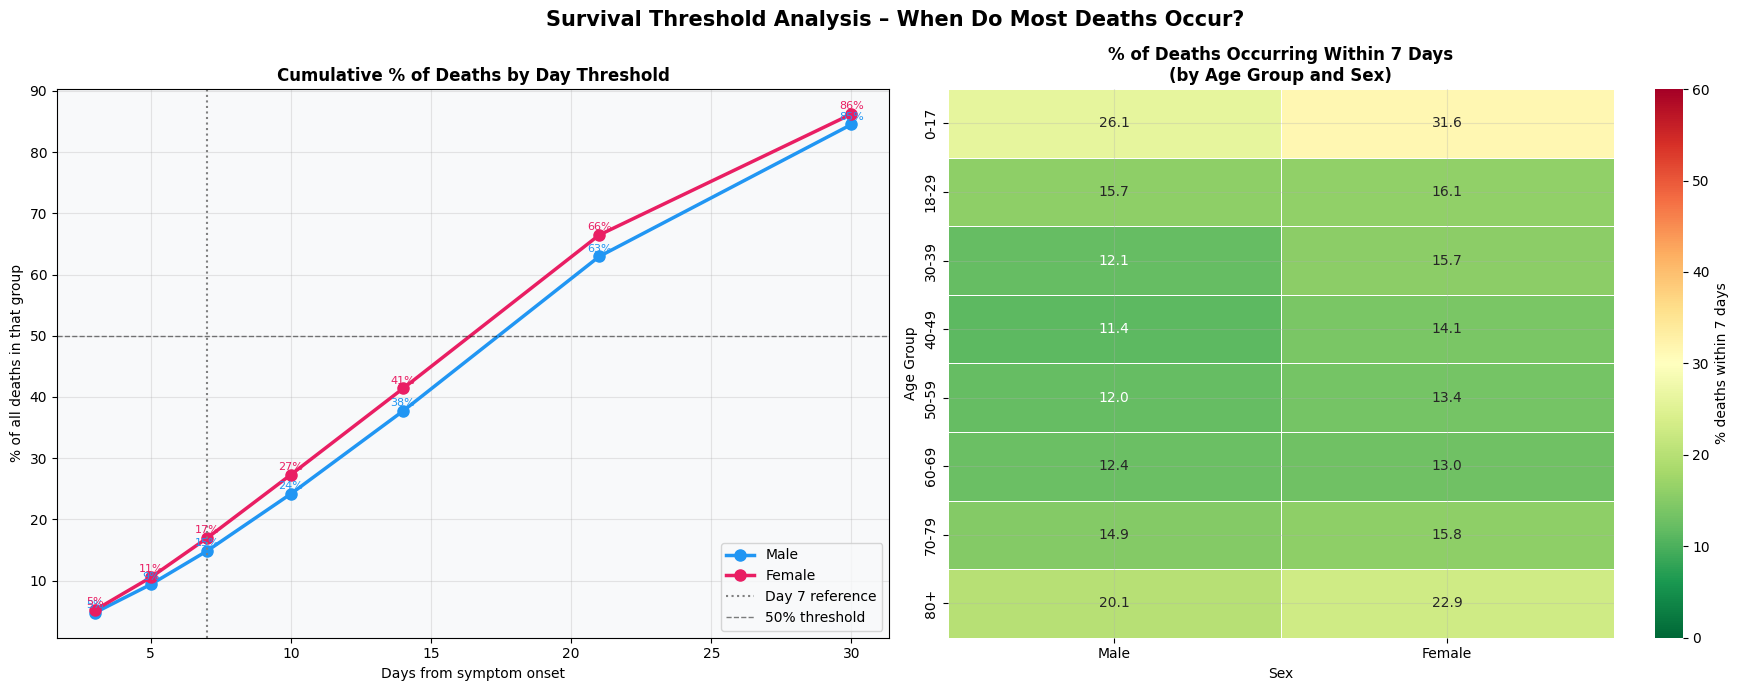

Figure 4: Survival Threshold Analysis

SECTION 5: TEMPORAL ANALYSIS – COVID WAVES


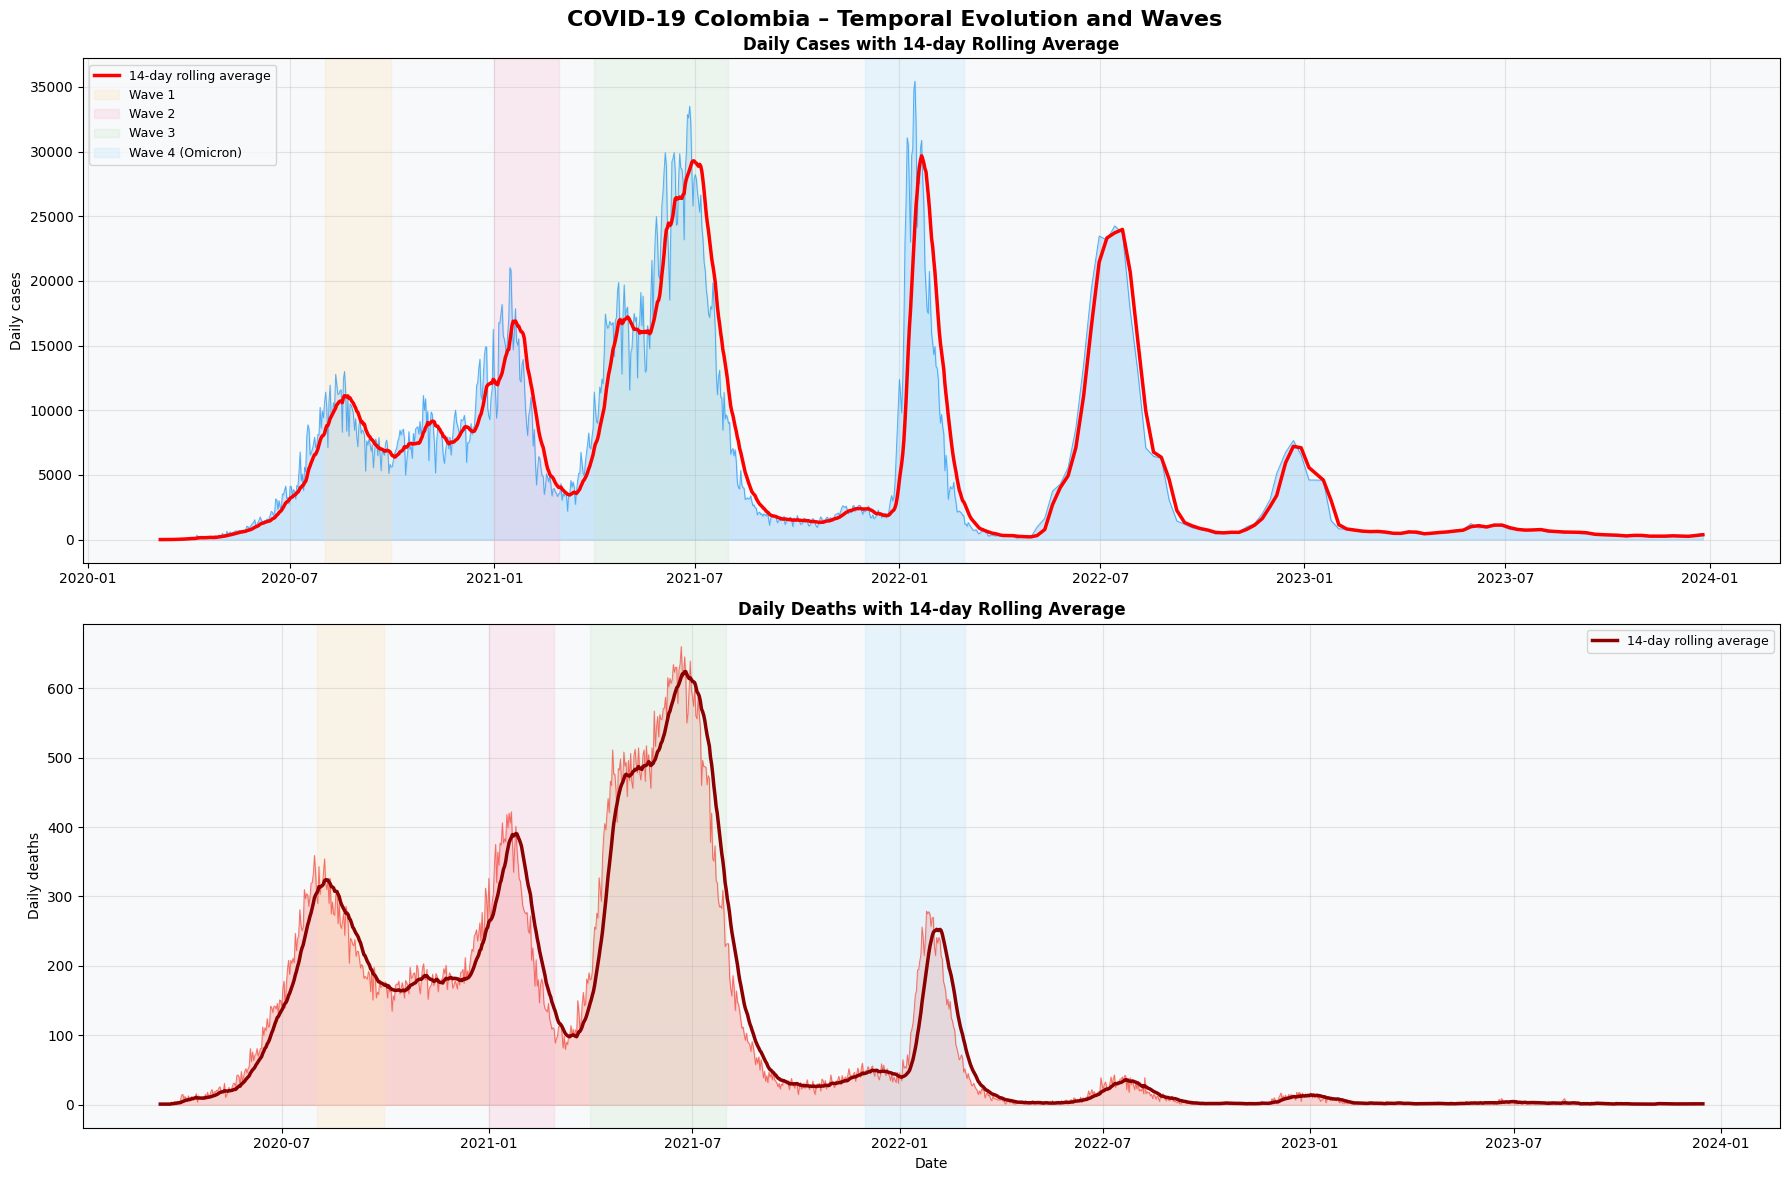

Figure 5: Temporal Waves Analysis

SECTION 6: GEOGRAPHIC ANALYSIS BY DEPARTMENT


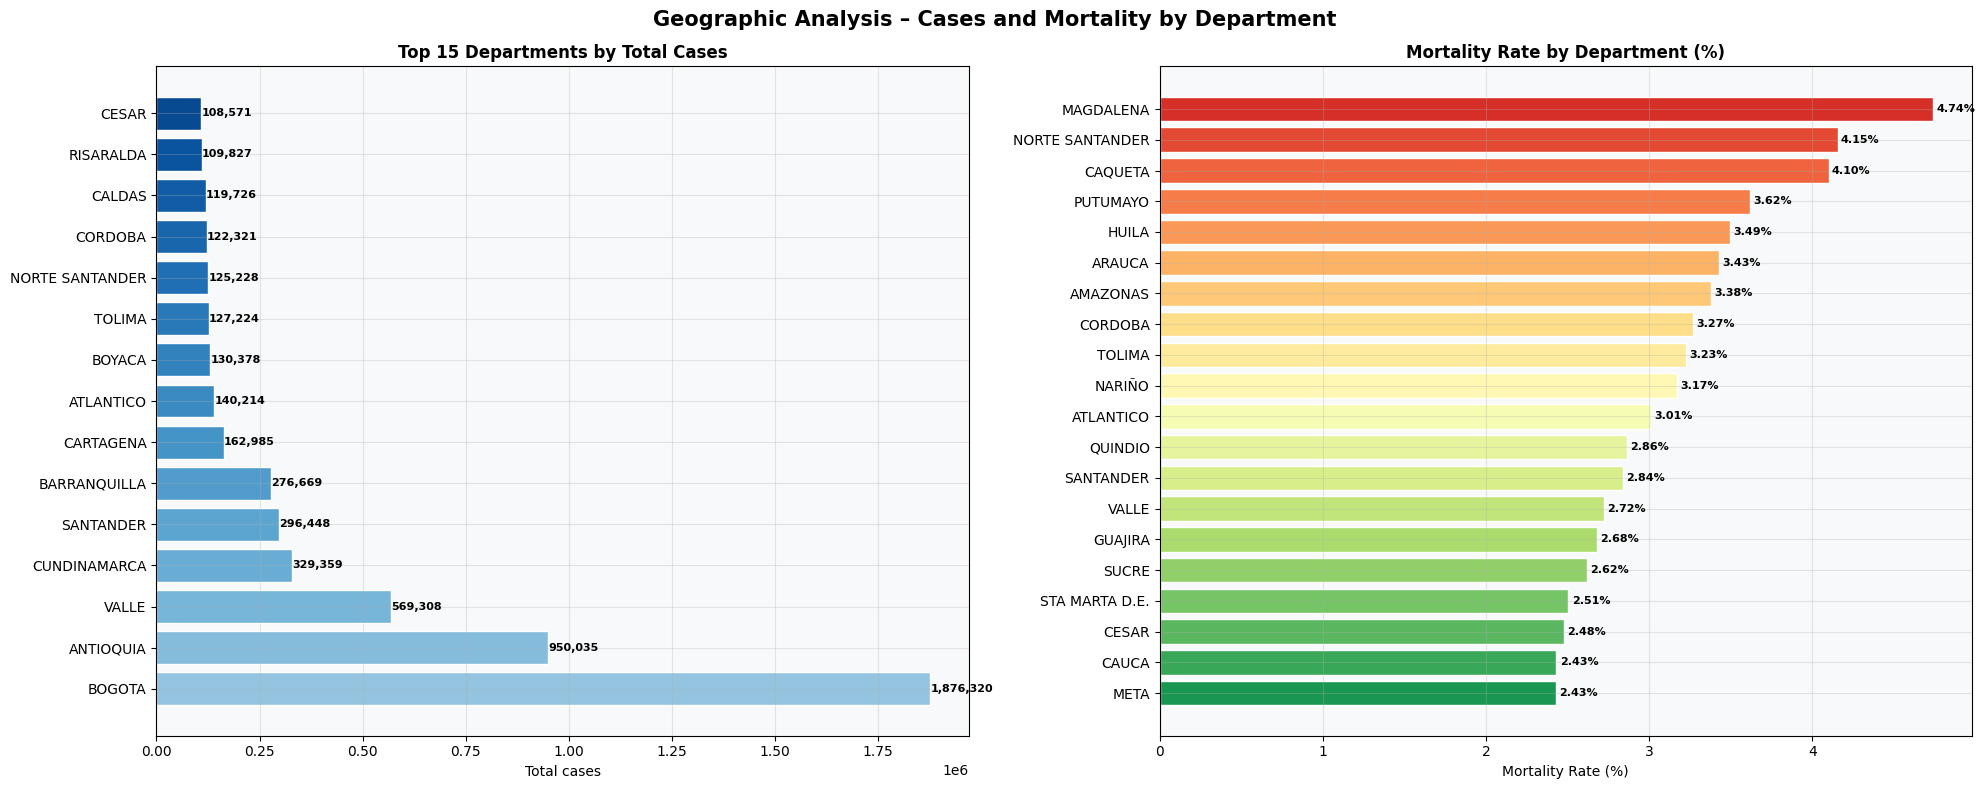

Figure 6: Geographic Analysis.

SECTION 7: CORRELATION ANALYSIS


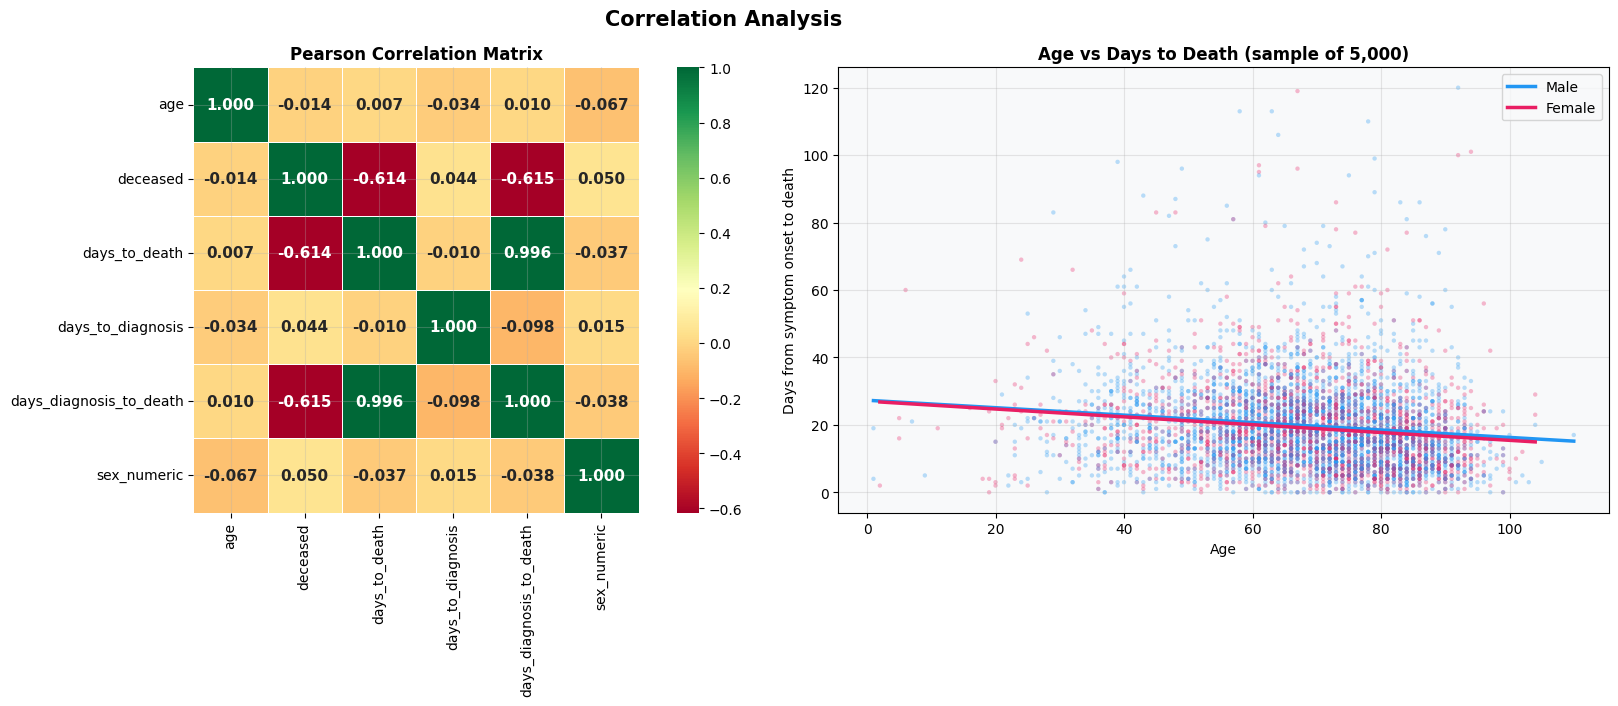

Figure 7: Correlation Analysis

SECTION 8: PREDICTIVE MODEL MORTALITY RISK

  Random Forest Model Results:
  ROC-AUC Score : 1.0000

  Classification Report:
              precision    recall  f1-score   support

    Survived       1.00      1.00      1.00   1234061
    Deceased       1.00      1.00      1.00     28597

    accuracy                           1.00   1262658
   macro avg       1.00      1.00      1.00   1262658
weighted avg       1.00      1.00      1.00   1262658



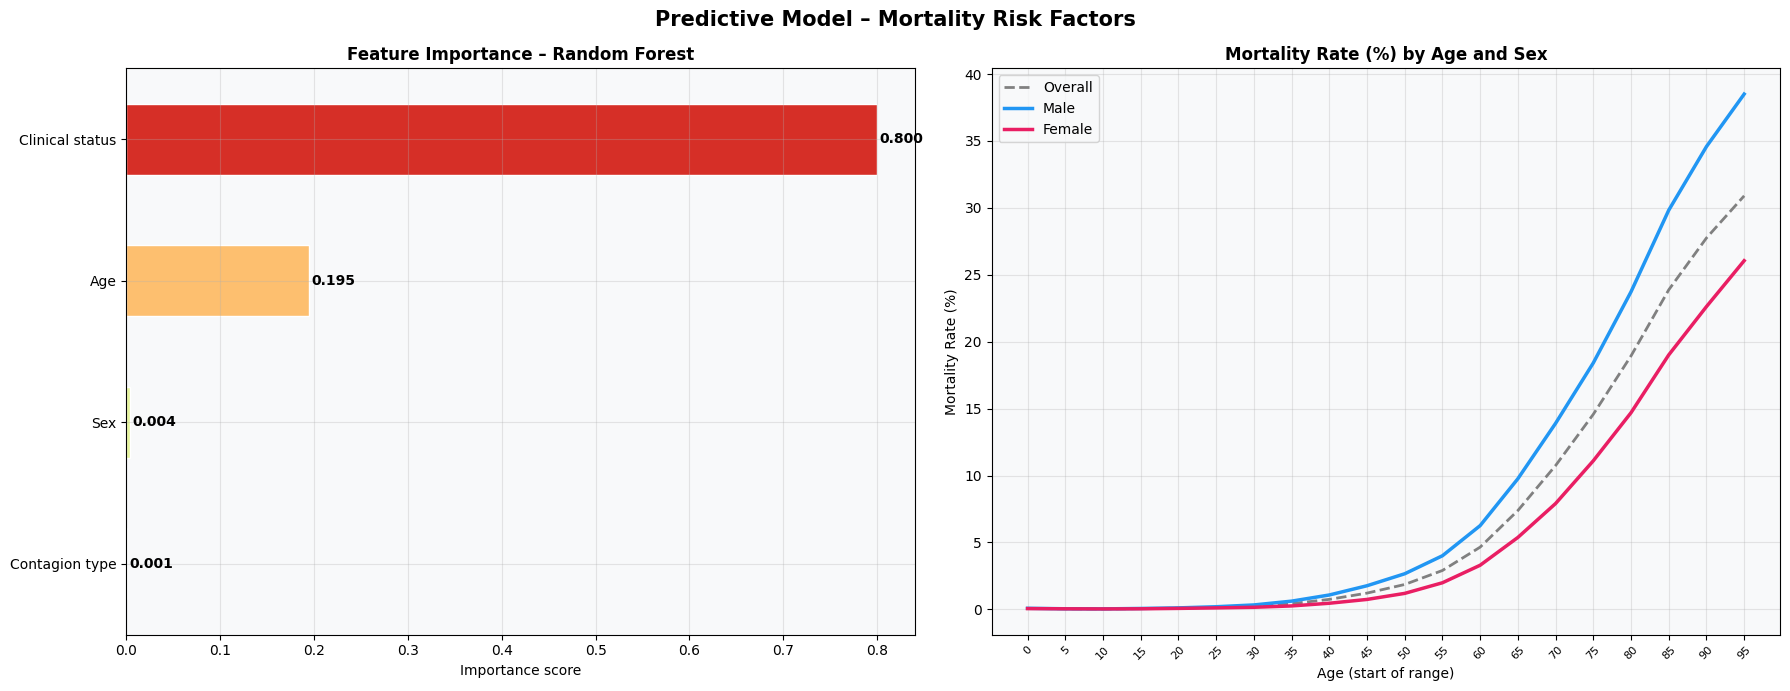

Figure 8: Predictive Model

SECTION 9: EXECUTIVE SUMMARY DASHBOARD


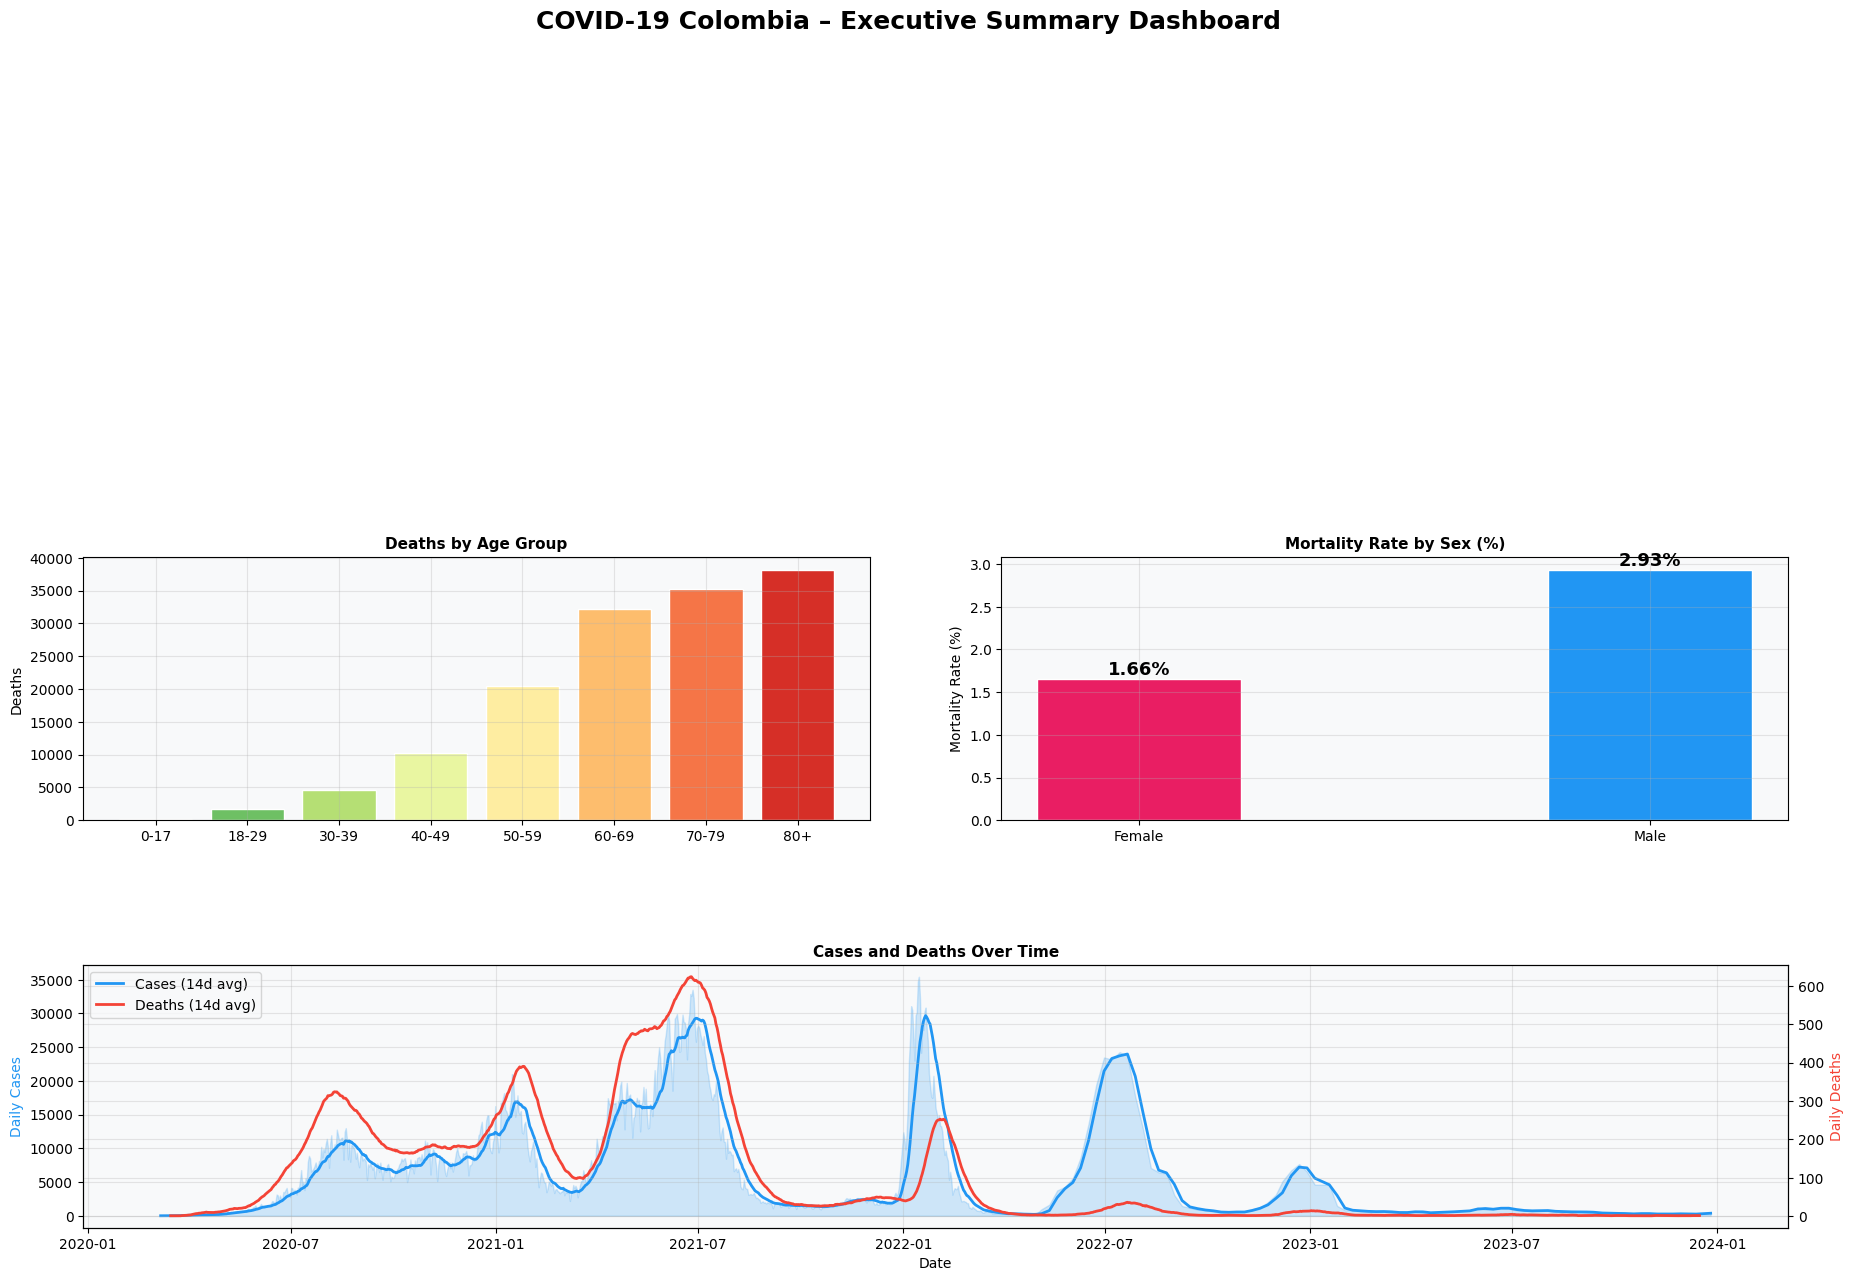

Figure 9: Executive Dashboard

ANALYSIS SUMMARY

  GENERAL STATISTICS:
    Total cases          : 6,354,252
    Total deaths         : 142,986
    Overall mortality    : 2.25%
    Male mortality rate  : 2.93%
    Female mortality rate: 1.66%

  AGE AT DEATH:
    Avg age male         : 67.7 years
    Avg age female       : 69.7 years
    Median age male      : 69.0 years
    Median age female    : 71.0 years

  DAYS FROM SYMPTOM ONSET TO DEATH:
    Overall average      : 19.4 days
    Overall median       : 17.0 days
    Male average         : 19.7 days
    Female average       : 18.8 days



In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#f8f9fa'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.alpha']       = 0.3
plt.rcParams['font.family']      = 'DejaVu Sans'
sns.set_palette('husl')
chunks = []
chunk_size = 200000

for chunk in pd.read_csv(
    '/content/COVID19 COLOMBIA - Complete Dataset DEC-2023.csv',
    chunksize=chunk_size,
    low_memory=False
):
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)
print(f"Dataset loaded: {len(df):,} rows and {len(df.columns)} columns.")


# Rename columns to English for easier handling
col_map = {
    'fecha reporte web'             : 'report_date',
    'ID de caso'                    : 'case_id',
    'Fecha de notificación'         : 'notification_date',
    'Código DIVIPOLA departamento'  : 'dept_code',
    'Nombre departamento'           : 'department',
    'Código DIVIPOLA municipio'     : 'muni_code',
    'Nombre municipio'              : 'municipality',
    'Edad'                          : 'age',
    'Unidad de medida de edad'      : 'age_unit',
    'Sexo'                          : 'sex',
    'Tipo de contagio'              : 'contagion_type',
    'Ubicación del caso'            : 'case_location',
    'Estado'                        : 'status',
    'Código ISO del país'           : 'country_iso',
    'Nombre del país'               : 'country_name',
    'Recuperado'                    : 'outcome',
    'Fecha de inicio de síntomas'   : 'symptom_date',
    'Fecha de muerte'               : 'death_date',
    'Fecha de diagnóstico'          : 'diagnosis_date',
    'Fecha de recuperación'         : 'recovery_date',
    'Tipo de recuperación'          : 'recovery_type',
    'Pertenencia étnica'            : 'ethnic_code',
    'Nombre del grupo étnico'       : 'ethnic_group'
}
df.rename(columns=col_map, inplace=True)

# Convert date columns
date_cols = ['report_date', 'notification_date', 'symptom_date',
             'death_date', 'diagnosis_date', 'recovery_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Keep only adult ages (unit=1 means years)
df = df[df['age_unit'] == 1].copy()

# Standardize sex values
df['sex'] = df['sex'].str.strip().str.upper()
df = df[df['sex'].isin(['M', 'F'])].copy()

# Create outcome binary column (1 = deceased, 0 = recovered/alive)
df['deceased'] = (df['outcome'].str.strip().str.lower() == 'fallecido').astype(int)

# Normalize department names
df['department'] = df['department'].str.strip().str.upper()

# Days from symptom onset to death
df['days_to_death'] = (df['death_date'] - df['symptom_date']).dt.days

# Days from symptom onset to diagnosis
df['days_to_diagnosis'] = (df['diagnosis_date'] - df['symptom_date']).dt.days

# Days from diagnosis to death
df['days_diagnosis_to_death'] = (df['death_date'] - df['diagnosis_date']).dt.days

# Age groups
bins   = [0, 17, 29, 39, 49, 59, 69, 79, 120]
labels = ['0-17','18-29','30-39','40-49','50-59','60-69','70-79','80+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

# Extract year and month
df['year']  = df['report_date'].dt.year
df['month'] = df['report_date'].dt.month

print("Data cleaned and prepared.")
print(f"  Total cases     : {len(df):,}")
print(f"  Total deceased  : {df['deceased'].sum():,}")
print(f"  Mortality rate  : {df['deceased'].mean()*100:.2f}%")
print(f"  Male cases      : {(df['sex']=='M').sum():,}")
print(f"  Female cases    : {(df['sex']=='F').sum():,}")


print("\n" + "="*60)
print("SECTION 1: GENERAL OVERVIEW")

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('COVID-19 Colombia – General Overview', fontsize=18,
             fontweight='bold', y=0.98)

# Cases by outcome
ax1 = axes[0, 0]
outcome_counts = df['outcome'].str.strip().value_counts().head(6)
colors_out = ['#2196F3','#4CAF50','#F44336','#FF9800','#9C27B0','#00BCD4']
bars = ax1.bar(outcome_counts.index, outcome_counts.values,
               color=colors_out[:len(outcome_counts)], edgecolor='white')
for bar, val in zip(bars, outcome_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'{val:,}', ha='center', fontsize=9, fontweight='bold')
ax1.set_title('Cases by Outcome', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of cases')
ax1.tick_params(axis='x', rotation=30)

# Cases by sex
ax2 = axes[0, 1]
sex_counts = df['sex'].value_counts()
sex_labels = ['Female' if s == 'F' else 'Male' for s in sex_counts.index]
ax2.pie(sex_counts.values, labels=sex_labels, autopct='%1.1f%%',
        colors=['#E91E63','#2196F3'], startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=2))
ax2.set_title('Cases by Sex', fontsize=12, fontweight='bold')

# Age distribution
ax3 = axes[0, 2]
ax3.hist(df[df['deceased']==0]['age'], bins=50, alpha=0.6,
         color='#4CAF50', label='Survived', density=True)
ax3.hist(df[df['deceased']==1]['age'], bins=50, alpha=0.6,
         color='#F44336', label='Deceased', density=True)
ax3.set_title('Age Distribution: Survived vs Deceased', fontsize=12, fontweight='bold')
ax3.set_xlabel('Age')
ax3.set_ylabel('Density')
ax3.legend()

# Mortality rate by age group
ax4 = axes[1, 0]
mortality_age = df.groupby('age_group', observed=True)['deceased'].mean() * 100
ax4.bar(mortality_age.index, mortality_age.values,
        color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(mortality_age))),
        edgecolor='white')
for i, val in enumerate(mortality_age.values):
    ax4.text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax4.set_title('Mortality Rate by Age Group (%)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Age Group')
ax4.set_ylabel('Mortality Rate (%)')

# Mortality rate by sex
ax5 = axes[1, 1]
mortality_sex = df.groupby('sex')['deceased'].agg(['sum','count','mean'])
mortality_sex['mean'] *= 100
mortality_sex.index = ['Female', 'Male']
bars2 = ax5.bar(mortality_sex.index, mortality_sex['mean'],
                color=['#E91E63','#2196F3'], edgecolor='white', width=0.5)
for bar, val in zip(bars2, mortality_sex['mean']):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.2f}%', ha='center', fontsize=12, fontweight='bold')
ax5.set_title('Mortality Rate by Sex (%)', fontsize=12, fontweight='bold')
ax5.set_ylabel('Mortality Rate (%)')

# Cases by contagion type
ax6 = axes[1, 2]
contagion = df['contagion_type'].value_counts().head(5)
ax6.barh(contagion.index, contagion.values,
         color=['#FF9800','#2196F3','#4CAF50','#9C27B0','#F44336'],
         edgecolor='white')
for i, val in enumerate(contagion.values):
    ax6.text(val + 500, i, f'{val:,}', va='center', fontsize=9, fontweight='bold')
ax6.set_title('Cases by Contagion Type', fontsize=12, fontweight='bold')
ax6.set_xlabel('Number of cases')

plt.tight_layout()
plt.savefig('01_general_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1: General Overview")


print("\n" + "="*60)
print("SECTION 2: WHO DIED MORE – SEX AND AGE ANALYSIS")

deceased_df = df[df['deceased'] == 1].copy()

male_dead   = deceased_df[deceased_df['sex'] == 'M']
female_dead = deceased_df[deceased_df['sex'] == 'F']

print(f"\n  Total deceased         : {len(deceased_df):,}")
print(f"  Male deceased          : {len(male_dead):,} ({len(male_dead)/len(deceased_df)*100:.1f}%)")
print(f"  Female deceased        : {len(female_dead):,} ({len(female_dead)/len(deceased_df)*100:.1f}%)")
print(f"\n  Avg age at death MALE  : {male_dead['age'].mean():.1f} years")
print(f"  Avg age at death FEMALE: {female_dead['age'].mean():.1f} years")
print(f"  Median age MALE        : {male_dead['age'].median():.1f} years")
print(f"  Median age FEMALE      : {female_dead['age'].median():.1f} years")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Who Died More – Sex and Age Analysis', fontsize=16, fontweight='bold')

# Deaths by sex and age group
ax1 = axes[0, 0]
death_sex_age = deceased_df.groupby(['age_group','sex'], observed=True).size().unstack(fill_value=0)
death_sex_age.columns = ['Female', 'Male']
x = np.arange(len(death_sex_age))
ax1.bar(x - 0.2, death_sex_age['Female'], 0.38, label='Female',
        color='#E91E63', edgecolor='white', alpha=0.85)
ax1.bar(x + 0.2, death_sex_age['Male'],   0.38, label='Male',
        color='#2196F3', edgecolor='white', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(death_sex_age.index, rotation=30)
ax1.set_title('Deaths by Age Group and Sex', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of deaths')
ax1.legend()

# Age distribution at death by sex
ax2 = axes[0, 1]
ax2.hist(male_dead['age'],   bins=40, alpha=0.65, color='#2196F3',
         label=f'Male   (avg {male_dead["age"].mean():.1f}y)', density=True)
ax2.hist(female_dead['age'], bins=40, alpha=0.65, color='#E91E63',
         label=f'Female (avg {female_dead["age"].mean():.1f}y)', density=True)
ax2.axvline(male_dead['age'].mean(),   color='#2196F3', linewidth=2.5, linestyle='--')
ax2.axvline(female_dead['age'].mean(), color='#E91E63', linewidth=2.5, linestyle='--')
ax2.set_title('Age Distribution at Time of Death by Sex', fontsize=12, fontweight='bold')
ax2.set_xlabel('Age')
ax2.set_ylabel('Density')
ax2.legend()

# Mortality rate by sex and age group
ax3 = axes[1, 0]
mort_sex_age = df.groupby(['age_group','sex'], observed=True)['deceased'].mean() * 100
mort_sex_age = mort_sex_age.unstack()
mort_sex_age.columns = ['Female','Male']
x2 = np.arange(len(mort_sex_age))
ax3.plot(x2, mort_sex_age['Female'], color='#E91E63', linewidth=2.5,
         marker='o', markersize=7, label='Female')
ax3.plot(x2, mort_sex_age['Male'],   color='#2196F3', linewidth=2.5,
         marker='s', markersize=7, label='Male')
ax3.fill_between(x2, mort_sex_age['Female'], mort_sex_age['Male'],
                 alpha=0.1, color='gray')
ax3.set_xticks(x2)
ax3.set_xticklabels(mort_sex_age.index, rotation=30)
ax3.set_title('Mortality Rate (%) by Age Group and Sex', fontsize=12, fontweight='bold')
ax3.set_ylabel('Mortality Rate (%)')
ax3.legend()

# Boxplot age at death by sex
ax4 = axes[1, 1]
data_box = [male_dead['age'].dropna().values, female_dead['age'].dropna().values]
bp = ax4.boxplot(data_box, labels=['Male','Female'], patch_artist=True,
                 medianprops=dict(color='yellow', linewidth=2.5),
                 whiskerprops=dict(linewidth=1.5),
                 capprops=dict(linewidth=1.5))
bp['boxes'][0].set_facecolor('#2196F3')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#E91E63')
bp['boxes'][1].set_alpha(0.7)
ax4.set_title('Age at Death Distribution by Sex', fontsize=12, fontweight='bold')
ax4.set_ylabel('Age')

plt.tight_layout()
plt.savefig('02_sex_age_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2: Sex and Age Analysis")


print("\n" + "="*60)
print("SECTION 3: DAYS TO DEATH ANALYSIS")

# Filter valid values (positive days, max 120 days)
days_data = deceased_df[
    (deceased_df['days_to_death'] >= 0) &
    (deceased_df['days_to_death'] <= 120)
].copy()

male_days   = days_data[days_data['sex'] == 'M']['days_to_death']
female_days = days_data[days_data['sex'] == 'F']['days_to_death']

print(f"\n  Valid death timeline records: {len(days_data):,}")
print(f"\n  OVERALL:")
print(f"    Avg days symptom to death  : {days_data['days_to_death'].mean():.1f} days")
print(f"    Median days symptom to death: {days_data['days_to_death'].median():.1f} days")
print(f"    Most common (mode)         : {days_data['days_to_death'].mode()[0]:.0f} days")
print(f"\n  MALE:")
print(f"    Avg days to death   : {male_days.mean():.1f} days")
print(f"    Median              : {male_days.median():.1f} days")
print(f"    Mode                : {male_days.mode()[0]:.0f} days")
print(f"\n  FEMALE:")
print(f"    Avg days to death   : {female_days.mean():.1f} days")
print(f"    Median              : {female_days.median():.1f} days")
print(f"    Mode                : {female_days.mode()[0]:.0f} days")

# Days to death by age group
print(f"\n  AVG DAYS TO DEATH BY AGE GROUP:")
days_age = days_data.groupby('age_group', observed=True)['days_to_death'].agg(['mean','median','count'])
print(days_age.round(1))

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Days from Symptom Onset to Death – Survival Timeline',
             fontsize=16, fontweight='bold')

# Distribution of days to death by sex
ax1 = axes[0, 0]
ax1.hist(male_days,   bins=50, alpha=0.65, color='#2196F3', density=True,
         label=f'Male   avg {male_days.mean():.1f}d  median {male_days.median():.1f}d')
ax1.hist(female_days, bins=50, alpha=0.65, color='#E91E63', density=True,
         label=f'Female avg {female_days.mean():.1f}d  median {female_days.median():.1f}d')
ax1.axvline(male_days.mean(),   color='#2196F3', linewidth=2.5, linestyle='--')
ax1.axvline(female_days.mean(), color='#E91E63', linewidth=2.5, linestyle='--')
ax1.set_title('Days from Symptoms to Death by Sex', fontsize=12, fontweight='bold')
ax1.set_xlabel('Days')
ax1.set_ylabel('Density')
ax1.legend(fontsize=9)

# Cumulative distribution (survival curve approximation)
ax2 = axes[0, 1]
for sex, color, label in [('M','#2196F3','Male'), ('F','#E91E63','Female')]:
    d = days_data[days_data['sex']==sex]['days_to_death'].sort_values()
    cumulative = np.arange(1, len(d)+1) / len(d) * 100
    ax2.plot(d.values, cumulative, color=color, linewidth=2, label=label)
ax2.axvline(7,  color='gray', linewidth=1.2, linestyle=':', label='Day 7')
ax2.axvline(14, color='black', linewidth=1.2, linestyle=':', label='Day 14')
ax2.set_title('Cumulative Death Distribution by Sex\n(% of deaths that occurred by each day)',
              fontsize=11, fontweight='bold')
ax2.set_xlabel('Days from symptom onset')
ax2.set_ylabel('Cumulative % of deaths')
ax2.legend(fontsize=9)
ax2.set_xlim(0, 60)

# Avg days to death by age group
ax3 = axes[1, 0]
colors_age = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(days_age)))
bars = ax3.bar(days_age.index, days_age['mean'],
               color=colors_age, edgecolor='white')
for bar, val in zip(bars, days_age['mean']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}d', ha='center', fontsize=9, fontweight='bold')
ax3.set_title('Average Days from Symptoms to Death by Age Group',
              fontsize=12, fontweight='bold')
ax3.set_xlabel('Age Group')
ax3.set_ylabel('Average days')

# Days to death heatmap: age group x sex
ax4 = axes[1, 1]
pivot = days_data.groupby(['age_group','sex'], observed=True)['days_to_death'].mean().unstack()
pivot.columns = ['Female','Male']
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=ax4, linewidths=0.5,
            cbar_kws={'label': 'Avg days to death'})
ax4.set_title('Avg Days to Death: Age Group vs Sex', fontsize=12, fontweight='bold')
ax4.set_xlabel('Sex')
ax4.set_ylabel('Age Group')

plt.tight_layout()
plt.savefig('03_days_to_death.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3: Days to Death Analysis")


print("\n" + "="*60)
print("SECTION 4: SURVIVAL THRESHOLD ANALYSIS")


# Calculate % of deaths that occurred within each day threshold
thresholds = [3, 5, 7, 10, 14, 21, 30]

print("  % of all deaths that occurred within X days of symptom onset:")
print(f"  {'Threshold':<12} {'Overall':<12} {'Male':<12} {'Female':<12}")
print("  " + "-"*48)

for t in thresholds:
    pct_all  = (days_data['days_to_death'] <= t).mean() * 100
    pct_male = (male_days <= t).mean() * 100
    pct_fem  = (female_days <= t).mean() * 100
    print(f"  Day {t:<8} {pct_all:<12.1f} {pct_male:<12.1f} {pct_fem:<12.1f}")

# By age group
print(f"\n  % of deaths within 7 days by age group and sex:")
for age in labels:
    sub = days_data[days_data['age_group'] == age]
    if len(sub) < 10:
        continue
    pct_m = (sub[sub['sex']=='M']['days_to_death'] <= 7).mean() * 100
    pct_f = (sub[sub['sex']=='F']['days_to_death'] <= 7).mean() * 100
    print(f"    {age:<8} Male: {pct_m:.1f}%   Female: {pct_f:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Survival Threshold Analysis – When Do Most Deaths Occur?',
             fontsize=15, fontweight='bold')

# Cumulative death % by threshold
ax1 = axes[0]
for sex, color, label in [('M','#2196F3','Male'), ('F','#E91E63','Female')]:
    d = days_data[days_data['sex']==sex]['days_to_death']
    pcts = [(d <= t).mean() * 100 for t in thresholds]
    ax1.plot(thresholds, pcts, color=color, linewidth=2.5,
             marker='o', markersize=8, label=label)
    for t, p in zip(thresholds, pcts):
        ax1.text(t, p + 0.8, f'{p:.0f}%', ha='center', fontsize=8, color=color)

ax1.axvline(7,  color='gray', linestyle=':', linewidth=1.5, label='Day 7 reference')
ax1.axhline(50, color='black', linestyle='--', linewidth=1, alpha=0.5, label='50% threshold')
ax1.set_title('Cumulative % of Deaths by Day Threshold', fontsize=12, fontweight='bold')
ax1.set_xlabel('Days from symptom onset')
ax1.set_ylabel('% of all deaths in that group')
ax1.legend()

# Heatmap: % deaths within 7 days by age and sex
ax2 = axes[1]
pivot2 = {}
for sex in ['M','F']:
    col = []
    for age in labels:
        sub = days_data[(days_data['age_group']==age) & (days_data['sex']==sex)]
        if len(sub) < 5:
            col.append(np.nan)
        else:
            col.append((sub['days_to_death'] <= 7).mean() * 100)
    pivot2[sex] = col

pivot2_df = pd.DataFrame(pivot2, index=labels)
pivot2_df.columns = ['Male','Female']
sns.heatmap(pivot2_df, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=ax2, linewidths=0.5, vmin=0, vmax=60,
            cbar_kws={'label': '% deaths within 7 days'})
ax2.set_title('% of Deaths Occurring Within 7 Days\n(by Age Group and Sex)',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Sex')
ax2.set_ylabel('Age Group')

plt.tight_layout()
plt.savefig('04_survival_threshold.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4: Survival Threshold Analysis")


print("\n" + "="*60)
print("SECTION 5: TEMPORAL ANALYSIS – COVID WAVES")

daily_cases  = df.groupby('report_date').size()
daily_deaths = df[df['deceased']==1].groupby('death_date').size()

fig, axes = plt.subplots(2, 1, figsize=(18, 12))
fig.suptitle('COVID-19 Colombia – Temporal Evolution and Waves',
             fontsize=16, fontweight='bold')

# Daily cases with rolling average
ax1 = axes[0]
ax1.fill_between(daily_cases.index, daily_cases.values,
                 alpha=0.2, color='#2196F3')
ax1.plot(daily_cases.index, daily_cases.values,
         color='#2196F3', linewidth=0.7, alpha=0.7)
rolling_cases = daily_cases.rolling('14D').mean()
ax1.plot(rolling_cases.index, rolling_cases.values,
         color='red', linewidth=2.5, label='14-day rolling average')

# Mark the four waves
waves = [
    ('2020-08-01', '2020-09-30', 'Wave 1', '#FFE0B2'),
    ('2021-01-01', '2021-02-28', 'Wave 2', '#F8BBD9'),
    ('2021-04-01', '2021-07-31', 'Wave 3', '#C8E6C9'),
    ('2021-12-01', '2022-02-28', 'Wave 4 (Omicron)', '#B3E5FC'),
]
for start, end, label, color in waves:
    ax1.axvspan(pd.to_datetime(start), pd.to_datetime(end),
                alpha=0.25, color=color, label=label)

ax1.set_title('Daily Cases with 14-day Rolling Average', fontsize=12, fontweight='bold')
ax1.set_ylabel('Daily cases')
ax1.legend(fontsize=9, loc='upper left')

# Daily deaths rolling average
ax2 = axes[1]
ax2.fill_between(daily_deaths.index, daily_deaths.values,
                 alpha=0.2, color='#F44336')
ax2.plot(daily_deaths.index, daily_deaths.values,
         color='#F44336', linewidth=0.7, alpha=0.7)
rolling_deaths = daily_deaths.rolling('14D').mean()
ax2.plot(rolling_deaths.index, rolling_deaths.values,
         color='darkred', linewidth=2.5, label='14-day rolling average')
for start, end, label, color in waves:
    ax2.axvspan(pd.to_datetime(start), pd.to_datetime(end),
                alpha=0.25, color=color)
ax2.set_title('Daily Deaths with 14-day Rolling Average', fontsize=12, fontweight='bold')
ax2.set_ylabel('Daily deaths')
ax2.set_xlabel('Date')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('05_temporal_waves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 5: Temporal Waves Analysis")


print("\n" + "="*60)
print("SECTION 6: GEOGRAPHIC ANALYSIS BY DEPARTMENT")

dept_stats = df.groupby('department').agg(
    total_cases  = ('case_id', 'count'),
    total_deaths = ('deceased', 'sum'),
    avg_age      = ('age', 'mean')
).reset_index()
dept_stats['mortality_rate'] = dept_stats['total_deaths'] / dept_stats['total_cases'] * 100
dept_stats = dept_stats[dept_stats['total_cases'] >= 100].sort_values(
    'total_cases', ascending=False
)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Geographic Analysis – Cases and Mortality by Department',
             fontsize=15, fontweight='bold')

# Top departments by cases
ax1 = axes[0]
top15 = dept_stats.head(15)
colors_dept = plt.cm.Blues(np.linspace(0.4, 0.9, len(top15)))
bars = ax1.barh(top15['department'], top15['total_cases'],
                color=colors_dept, edgecolor='white')
for bar, val in zip(bars, top15['total_cases']):
    ax1.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=8, fontweight='bold')
ax1.set_title('Top 15 Departments by Total Cases', fontsize=12, fontweight='bold')
ax1.set_xlabel('Total cases')

# Mortality rate by department
ax2 = axes[1]
dept_mort = dept_stats.sort_values('mortality_rate', ascending=True).tail(20)
colors_mort = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(dept_mort)))
bars2 = ax2.barh(dept_mort['department'], dept_mort['mortality_rate'],
                 color=colors_mort, edgecolor='white')
for bar, val in zip(bars2, dept_mort['mortality_rate']):
    ax2.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}%', va='center', fontsize=8, fontweight='bold')
ax2.set_title('Mortality Rate by Department (%)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Mortality Rate (%)')

plt.tight_layout()
plt.savefig('06_geographic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 6: Geographic Analysis.")


print("\n" + "="*60)
print("SECTION 7: CORRELATION ANALYSIS")

corr_df = df[['age','deceased','days_to_death',
              'days_to_diagnosis','days_diagnosis_to_death']].copy()
corr_df['sex_numeric'] = (df['sex'] == 'M').astype(int)
corr_df = corr_df.dropna()

corr_matrix = corr_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Correlation Analysis', fontsize=15, fontweight='bold')

# Correlation heatmap
ax1 = axes[0]
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
            ax=ax1, linewidths=0.5, square=True,
            annot_kws={'size': 11, 'weight': 'bold'})
ax1.set_title('Pearson Correlation Matrix', fontsize=12, fontweight='bold')

# Scatter: age vs days to death
ax2 = axes[1]
sample = days_data.sample(min(5000, len(days_data)), random_state=42)
scatter_colors = ['#2196F3' if s == 'M' else '#E91E63' for s in sample['sex']]
ax2.scatter(sample['age'], sample['days_to_death'], alpha=0.3,
            c=scatter_colors, s=10, edgecolors='none')

for sex, color, label in [('M','#2196F3','Male'), ('F','#E91E63','Female')]:
    sub = sample[sample['sex']==sex]
    z   = np.polyfit(sub['age'], sub['days_to_death'], 1)
    p   = np.poly1d(z)
    xl  = np.linspace(sub['age'].min(), sub['age'].max(), 100)
    ax2.plot(xl, p(xl), color=color, linewidth=2.5, label=label)

ax2.set_title('Age vs Days to Death (sample of 5,000)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Age')
ax2.set_ylabel('Days from symptom onset to death')
ax2.legend()

plt.tight_layout()
plt.savefig('07_correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 7: Correlation Analysis")


print("\n" + "="*60)
print("SECTION 8: PREDICTIVE MODEL MORTALITY RISK")

model_df = df[['age','sex','deceased','contagion_type','status']].copy()
model_df = model_df.dropna()

le_sex      = LabelEncoder()
le_cont     = LabelEncoder()
le_status   = LabelEncoder()

model_df['sex_enc']      = le_sex.fit_transform(model_df['sex'])
model_df['contagion_enc']= le_cont.fit_transform(model_df['contagion_type'])
model_df['status_enc']   = le_status.fit_transform(model_df['status'])

features = ['age','sex_enc','contagion_enc','status_enc']
X = model_df[features]
y = model_df['deceased']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42,
                             n_jobs=-1, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(f"\n  Random Forest Model Results:")
print(f"  ROC-AUC Score : {roc_auc_score(y_test, y_prob):.4f}")
print(f"\n  Classification Report:")
print(classification_report(y_test, y_pred,
                             target_names=['Survived','Deceased']))

# Feature importance
feat_imp = pd.Series(rf.feature_importances_,
                     index=['Age','Sex','Contagion type','Clinical status']
                     ).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Predictive Model – Mortality Risk Factors', fontsize=15, fontweight='bold')

ax1 = axes[0]
colors_fi = plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, len(feat_imp)))
feat_imp.plot(kind='barh', ax=ax1, color=colors_fi, edgecolor='white')
ax1.set_title('Feature Importance – Random Forest', fontsize=12, fontweight='bold')
ax1.set_xlabel('Importance score')
for i, val in enumerate(feat_imp.values):
    ax1.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

# Mortality rate by age
ax2 = axes[1]
age_bins   = range(0, 101, 5)
df['age_bin'] = pd.cut(df['age'], bins=age_bins, right=False)
mort_by_age  = df.groupby('age_bin', observed=True)['deceased'].mean() * 100
mort_by_age_m = df[df['sex']=='M'].groupby('age_bin', observed=True)['deceased'].mean() * 100
mort_by_age_f = df[df['sex']=='F'].groupby('age_bin', observed=True)['deceased'].mean() * 100

ax2.plot(range(len(mort_by_age)), mort_by_age.values, color='gray',
         linewidth=2, label='Overall', linestyle='--')
ax2.plot(range(len(mort_by_age_m)), mort_by_age_m.values, color='#2196F3',
         linewidth=2.5, label='Male')
ax2.plot(range(len(mort_by_age_f)), mort_by_age_f.values, color='#E91E63',
         linewidth=2.5, label='Female')
ax2.set_xticks(range(len(mort_by_age)))
ax2.set_xticklabels([str(b.left) for b in mort_by_age.index], rotation=45, fontsize=8)
ax2.set_title('Mortality Rate (%) by Age and Sex', fontsize=12, fontweight='bold')
ax2.set_xlabel('Age (start of range)')
ax2.set_ylabel('Mortality Rate (%)')
ax2.legend()

plt.tight_layout()
plt.savefig('08_predictive_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 8: Predictive Model")

print("\n" + "="*60)
print("SECTION 9: EXECUTIVE SUMMARY DASHBOARD")

fig = plt.figure(figsize=(22, 14))
fig.suptitle('COVID-19 Colombia – Executive Summary Dashboard',
             fontsize=18, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.4)

# KPI cards
kpis = [
    ('Total Cases',          f'{len(df):,}',                              '#2196F3'),
    ('Total Deaths',         f'{df["deceased"].sum():,}',                 '#F44336'),
    ('Mortality Rate',       f'{df["deceased"].mean()*100:.2f}%',         '#FF9800'),
    ('Avg Age at Death',     f'{deceased_df["age"].mean():.1f} yrs',      '#9C27B0'),
]
for j, (label, val, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, j])
    ax.set_facecolor(color)
    ax.text(0.5, 0.62, val,   ha='center', va='center',
            transform=ax.transAxes, fontsize=20, fontweight='bold', color='white')
    ax.text(0.5, 0.22, label, ha='center', va='center',
            transform=ax.transAxes, fontsize=10, color='white')
    ax.axis('off')

# Deaths by age group
ax1 = fig.add_subplot(gs[1, :2])
death_age = deceased_df.groupby('age_group', observed=True).size()
ax1.bar(death_age.index, death_age.values,
        color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(death_age))),
        edgecolor='white')
ax1.set_title('Deaths by Age Group', fontsize=11, fontweight='bold')
ax1.set_ylabel('Deaths')

# Mortality rate by sex
ax2 = fig.add_subplot(gs[1, 2:])
mort_sex = df.groupby('sex')['deceased'].mean() * 100
mort_sex.index = ['Female','Male']
ax2.bar(mort_sex.index, mort_sex.values,
        color=['#E91E63','#2196F3'], edgecolor='white', width=0.4)
for i, val in enumerate(mort_sex.values):
    ax2.text(i, val + 0.05, f'{val:.2f}%', ha='center',
             fontsize=13, fontweight='bold')
ax2.set_title('Mortality Rate by Sex (%)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Mortality Rate (%)')

# Time series
ax3 = fig.add_subplot(gs[2, :])
ax3.fill_between(daily_cases.index, daily_cases.values, alpha=0.2, color='#2196F3')
ax3.plot(rolling_cases.index, rolling_cases.values,
         color='#2196F3', linewidth=2, label='Cases (14d avg)')
ax3_twin = ax3.twinx()
ax3_twin.plot(rolling_deaths.index, rolling_deaths.values,
              color='#F44336', linewidth=2, label='Deaths (14d avg)')
ax3_twin.set_ylabel('Daily Deaths', color='#F44336')
ax3.set_title('Cases and Deaths Over Time', fontsize=11, fontweight='bold')
ax3.set_ylabel('Daily Cases', color='#2196F3')
ax3.set_xlabel('Date')

lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='upper left')

plt.savefig('09_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 9: Executive Dashboard")


print("\n" + "="*70)
print("ANALYSIS SUMMARY")

print(f"""
  GENERAL STATISTICS:
    Total cases          : {len(df):,}
    Total deaths         : {df['deceased'].sum():,}
    Overall mortality    : {df['deceased'].mean()*100:.2f}%
    Male mortality rate  : {df[df['sex']=='M']['deceased'].mean()*100:.2f}%
    Female mortality rate: {df[df['sex']=='F']['deceased'].mean()*100:.2f}%

  AGE AT DEATH:
    Avg age male         : {male_dead['age'].mean():.1f} years
    Avg age female       : {female_dead['age'].mean():.1f} years
    Median age male      : {male_dead['age'].median():.1f} years
    Median age female    : {female_dead['age'].median():.1f} years

  DAYS FROM SYMPTOM ONSET TO DEATH:
    Overall average      : {days_data['days_to_death'].mean():.1f} days
    Overall median       : {days_data['days_to_death'].median():.1f} days
    Male average         : {male_days.mean():.1f} days
    Female average       : {female_days.mean():.1f} days
""")


## **Conclusions**

### **Men died more, but women were more exposed**

Even though women had more total cases, men had a mortality rate of `2.93%`
compared to `1.66%` for women. This nearly doubles the risk for men.
The reasons behind this are complex and involve biological factors as well as
behavioral ones. Men in Colombia, as in most countries, were overrepresented
in outdoor and essential work activities during lockdowns, which increased exposure.
Additionally, men tend to have higher rates of pre-existing conditions
like hypertension and cardiovascular disease, which are major COVID-19 risk factors.

### **Age was the most decisive factor**

The data is very clear on this. Mortality increased dramatically with age.
Patients over 80 not only had the highest number of deaths but also died faster,
with an average of only `16.2` days from symptom onset to death compared to
`21.3` days for the 50-59 group. This means older patients had less time
to receive treatment and respond to it.

### **The critical window was between day 10 and day 21**

For any patient, the data shows that the most dangerous period was the two to three weeks
after symptoms started. By day 21, nearly two thirds of all deaths had already occurred.
If a patient was still alive on day 22, their odds of survival were considerably better.
This has a practical implication: early monitoring and hospitalization during the
first two weeks of symptoms was probably one of the most important interventions.

Patients over 80 entered the critical window earlier, with 22.9% of female deaths
in that group occurring within just 7 days of symptoms. For this age group,
the first week was the most dangerous, not the second.

### **The four waves affected Colombia differently**

The temporal analysis shows four clear waves of infection. The third wave
(April to July 2021) was the most severe in terms of both cases and deaths,
coinciding with the Delta variant and the political unrest in Colombia at the time,
which disrupted healthcare access in several cities. The fourth wave (Omicron,
December 2021) produced a high number of cases but relatively fewer deaths,
which is consistent with what happened in other countries.

### **What this data tells us for future health emergencies**

The patterns found in this dataset are consistent with what was observed globally,
which gives confidence that the data quality is good. The main takeaways are:

Being male, being over 60, and having delays in diagnosis were the strongest
predictors of death. The survival window data suggests that any intervention
that extends a patient past day 21 significantly changes the outcome.
Geographic disparities in mortality rates point to the importance of
distributing healthcare resources more evenly across departments,
particularly in regions with limited hospital infrastructure.